# Compare RAiDER, PyAPS, GACOS (ARIA) - Explicit Notebook Workflow

This notebook converts the script `Compare_RAiDER_PyAPS_GACOS.py` into an explicit cell-by-cell analysis workflow.

Run sequentially from top to bottom.

In [1]:
import glob
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio as rio
from rasterio.transform import rowcol
from scipy.ndimage import map_coordinates
from scipy.interpolate import griddata

try:
    from pyaps3 import PyAPS, ECMWFdload
except ImportError:
    PyAPS = None
    ECMWFdload = None
    NARRdload = None
    MERRAdload = None

print('PyAPS available:', PyAPS is not None)

PyAPS available: True


### Define Plotting Functions 
In this section we define functions needed to read the interferogram data from the ARIA products and perform DEM intersection, as well as data plotting.  

In [2]:
def read_netcdf(file_path, group=None, engine='netcdf4'):
    try:
        ds = xr.open_dataset(file_path, group=group, engine=engine)
        return ds
    except Exception as e:
        raise RuntimeError(f'Failed reading {file_path} (group={group}): {e}')

def phase2disp(phase, wavelength=0.05546, sign_flip=False):
    disp = wavelength * phase / (4 * np.pi)
    if sign_flip:
        disp = -disp
    return disp

def plot_variable(dataset, lat, lon, ph2disp=True, crange=None, unit_is_disp=False, figname='phase_map.png'):
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    if ph2disp:
        values = 1000 * phase2disp(dataset, sign_flip=False)
    else:
        values = dataset

    if crange is not None:
        vmax = crange
    else:
        vmax = np.nanpercentile(np.abs(values), 95)

    im = ax.pcolormesh(lon, lat, values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    ax.gridlines(draw_labels={'bottom':'x','left':'y'}, linewidth=0.4, color='gray', alpha=0.6)
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', location='top', pad=0.02, shrink=0.5)
    if ph2disp or unit_is_disp:
        cbar.set_label('Displacement (mm)', fontsize=12)
    else:
        cbar.set_label('Unwrapped Phase (radians)', fontsize=12)
    plt.tight_layout()
    plt.savefig(figname, dpi=300)
    plt.show()
    plt.close()
    

def extract_tropo(aria_file, model='ERA5'):
    ds_ref = read_netcdf(aria_file, group=f'/science/grids/corrections/external/troposphere/{model}/reference')
    ds_sec = read_netcdf(aria_file, group=f'/science/grids/corrections/external/troposphere/{model}/secondary')
    sec = ds_sec['troposphereWet'] + ds_sec['troposphereHydrostatic']
    ref = ds_ref['troposphereWet'] + ds_ref['troposphereHydrostatic']
    tropo = phase2disp(sec, sign_flip=True) - phase2disp(ref, sign_flip=True)
    return tropo


def read_phase(aria_file):
    ds = read_netcdf(aria_file, group='/science/grids/data')
    unw = ds['unwrappedPhase']
    def _get_coord(name_list):
        for nm in name_list:
            if nm in ds.coords:
                return ds.coords[nm].values
        return None
    lats = _get_coord(['latitude','lat','latitudeMeta','latMeta'])
    lons = _get_coord(['longitude','lon','longitudeMeta','lonMeta'])
    if lats is None or lons is None:
        raise KeyError('latitude/longitude coordinate not found in dataset')
    center_lon = np.mean(lons)
    center_lat = np.mean(lats)
    ref_val = unw.sel(longitude=center_lon, latitude=center_lat, method='nearest')
    unw = (unw - ref_val).values
    return unw, lats, lons


We also have some functions for reaching a DEM and performing 3D interpolation. 

In [4]:
def read_dem(dem_file, lats, lons):
    with rio.open(dem_file) as src:
        data = src.read(1)
        if lats.ndim == 1 and lons.ndim == 1:
            lons_grid, lats_grid = np.meshgrid(lons, lats)
        else:
            lats_grid = lats
            lons_grid = lons
        inv_transform = ~src.transform
        rows, cols = rowcol(inv_transform, lons_grid.ravel(), lats_grid.ravel())
        rows = np.array(rows).reshape(lats_grid.shape)
        cols = np.array(cols).reshape(lons_grid.shape)
        heights = map_coordinates(data, [rows, cols], order=1, mode='nearest')
    return heights

def intersectDEM(tropo_dataArray, lats, lons, dem_file):
    hgts = read_dem(dem_file, lats, lons)
    X, Y = np.meshgrid(lons, lats)
    new_x = xr.DataArray(X, dims=('y_new','x_new'))
    new_y = xr.DataArray(Y, dims=('y_new','x_new'))
    new_z = xr.DataArray(hgts, dims=('y_new','x_new'))

    mean_lat = np.mean(lats)
    mean_lon = np.mean(lons)
    y_idx = np.argmin(np.abs(new_y.values[:,0] - mean_lat))
    x_idx = np.argmin(np.abs(new_x.values[0,:] - mean_lon))

    tropo_interp = tropo_dataArray.interp(longitudeMeta=new_x, latitudeMeta=new_y, heightsMeta=new_z, method='linear')
    tropo_interp = tropo_interp - tropo_interp.isel(y_new=y_idx, x_new=x_idx)
    return tropo_interp

Here we include a function for running PyAPS and interpolating the PyAPS delays to the interferogram pixels. 

In [5]:
def plot_pyaps(date1, date2, lats=None, lons=None, dem_file='dem.tif', model='ERA5', crange=None):
    if PyAPS is None:
        print('PyAPS unavailable; install pyaps3 for this step')
        return
    bbox = (np.min(lats), np.max(lats), np.min(lons), np.max(lons))
    grib_files = ECMWFdload(bdate=[date1,date2], hr=['00','00'], filedir='pyaps', model=model, humidity='Q', snwe=bbox)
    dem = read_dem(dem_file, lats, lons)
    lons_grid, lats_grid = np.meshgrid(lons, lats)
    p1 = PyAPS(grib_files[0], dem, lats_grid, lons_grid, model=model).getdelay()
    p2 = PyAPS(grib_files[1], dem, lats_grid, lons_grid, model=model).getdelay()
    out = p2 - p1
    out = out - np.nanmean(out)
    plot_variable(1000*out, lats, lons, ph2disp=False, unit_is_disp=True, crange=crange, figname=f'pyaps_{date1}_{date2}_delay.png')

Finally, we have a function for reading and plotting GACOS delays. 
Typically these would need to be downloaded from www.gacos.net prior to running this code. 
In this case we have made the delays available in the accompanying dataset. 

In [6]:
def plot_GACOS(date1, date2, out_lats=None, out_lons=None, data_dir='GACOS', crange=None):
    gacos_file_1 = os.path.join(data_dir, f'{date1}.ztd.tif')
    gacos_file_2 = os.path.join(data_dir, f'{date2}.ztd.tif')
    if not (os.path.exists(gacos_file_1) and os.path.exists(gacos_file_2)):
        raise FileNotFoundError('GACOS files missing')
    ds1 = rio.open(gacos_file_1)
    ds2 = rio.open(gacos_file_2)
    tropo = ds2.read(1) - ds1.read(1)
    transform = ds1.transform
    h, w = ds1.height, ds1.width
    cols, rows = np.meshgrid(np.arange(w), np.arange(h))
    src_lons, src_lats = rio.transform.xy(transform, rows, cols, offset='center')
    src_lons = np.array(src_lons); src_lats = np.array(src_lats)
    if out_lats is None or out_lons is None:
        out_lons = src_lons[0,:]; out_lats = src_lats[:,0]
        zvals = tropo
    else:
        if out_lats.ndim == 1 and out_lons.ndim == 1:
            out_lon_g, out_lat_g = np.meshgrid(out_lons, out_lats)
        else:
            out_lon_g, out_lat_g = out_lons, out_lats
        zvals = griddata(np.column_stack((src_lons.ravel(), src_lats.ravel())), tropo.ravel(), (out_lon_g, out_lat_g), method='nearest')
    mean_lat = np.mean(out_lats); mean_lon = np.mean(out_lons)
    y_idx = np.argmin(np.abs(out_lats - mean_lat)); x_idx = np.argmin(np.abs(out_lons - mean_lon))
    zvals = zvals - zvals[y_idx, x_idx]
    plot_variable(1000*zvals, out_lats, out_lons, ph2disp=False, unit_is_disp=True, crange=crange, figname=f'GACOS_{date1}_{date2}_tropospheric_delay.png')

### Running the example

In this example we will run RAiDER to generate delays from ERA-5 for the ARIA products in this example tutorial. 
To begin we need to run RAiDER for each product in our example dataset. 

In [14]:
# If you are running a new file, you would use the following command to produce ERA-5 delays within the ARIA product
# !raider.py ++process calcDelaysGUNW -m ERA5 -f products/S1-GUNW-A-R-064-tops-20250912_20250831-014931-00119W_00033N-PP-e54e-v3_0_1.nc

Once the ERA5 delays have been downloaded, we can now run the comparison with the existing GACOS data and with PyAPS. 

ARIA file products/S1-GUNW-A-R-064-tops-20250912_20250906-014931-00119W_00033N-PP-9580-v3_0_1.nc
DEM exists True
GACOS tifs ['GACOS/20250819.ztd.tif', 'GACOS/20250831.ztd.tif', 'GACOS/20250906.ztd.tif', 'GACOS/20250912.ztd.tif']


/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDE

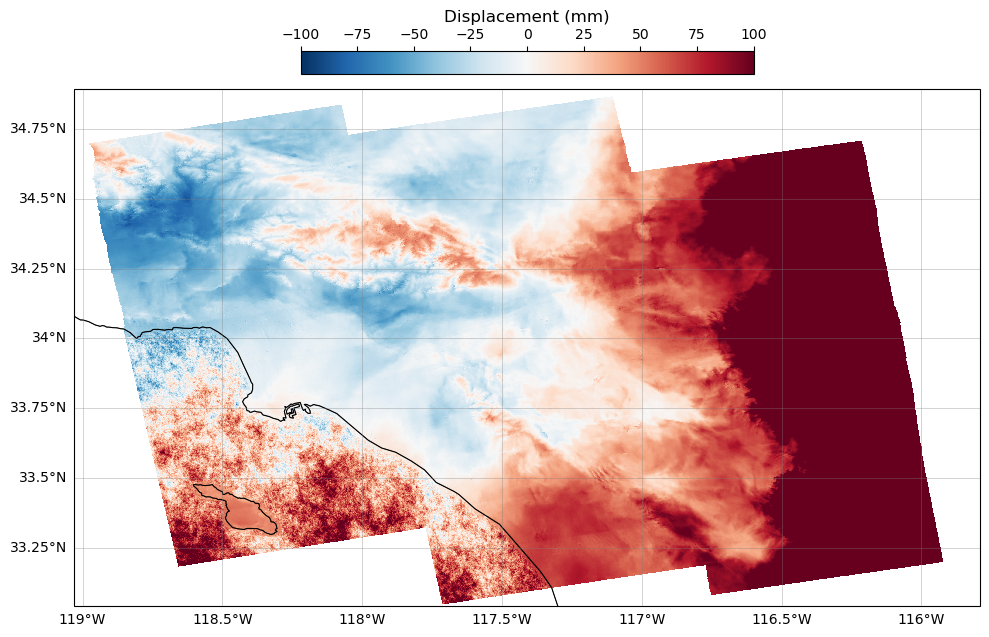

In [18]:
# change dates to correspond to the correct ARIA product
date1 = '20250912' 
date2 = '20250906' # can also use 20250831 or 20250819

# color bar color range
crange = 100

# check that the aria files are found
aria_files = glob.glob(f'products/S1-GUNW-A-R-*{date1}_{date2}*.nc')
assert aria_files, 'No ARIA product found'
aria_file = aria_files[0]

# check that the DEM file exists
assert os.path.exists('dem.tif'), 'dem.tif must exist'

# print out the basic info for this comparison
print('ARIA file', aria_file)
print('DEM exists', os.path.exists('dem.tif'))
print('GACOS tifs', sorted(glob.glob('GACOS/*.ztd.tif')))

# extract the interferogram from the ARIA product and plot it
unw, lats, lons = read_phase(aria_file)
plot_variable(unw, lats, lons, ph2disp=True, crange=crange, figname=f'unwrapped_phase_{date1}_{date2}.png')

processing HRRR


/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDE

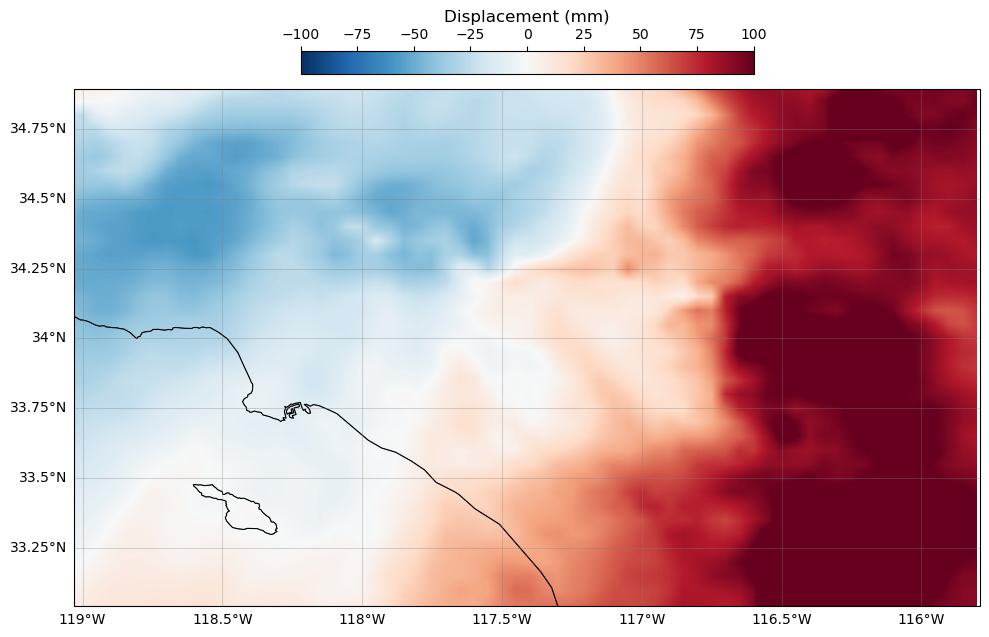

processing ERA5


/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDE

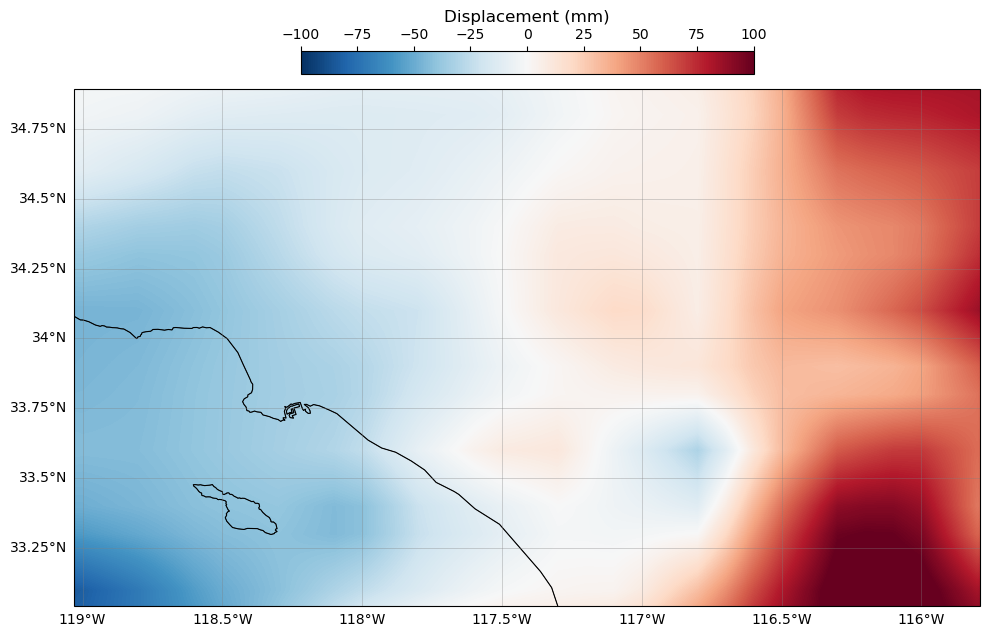

In [19]:
# plot the weather models generated from RAiDER
# Note that HRRR was generated automatically for the product during production
for model in ['HRRR', 'ERA5']:
    print('processing', model)
    tropo = extract_tropo(aria_file, model=model)
    tropo_interp = intersectDEM(tropo, lats, lons, 'dem.tif')
    plot_variable(1000*tropo_interp.values, lats, lons, ph2disp=False, unit_is_disp=True, crange=crange, figname=f'{model}_tropospheric_delay_{date1}_{date2}.png')

Processing GACOS delays


/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDER/lib/python3.12/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/jlmd9g/software/miniforge3/envs/RAiDE

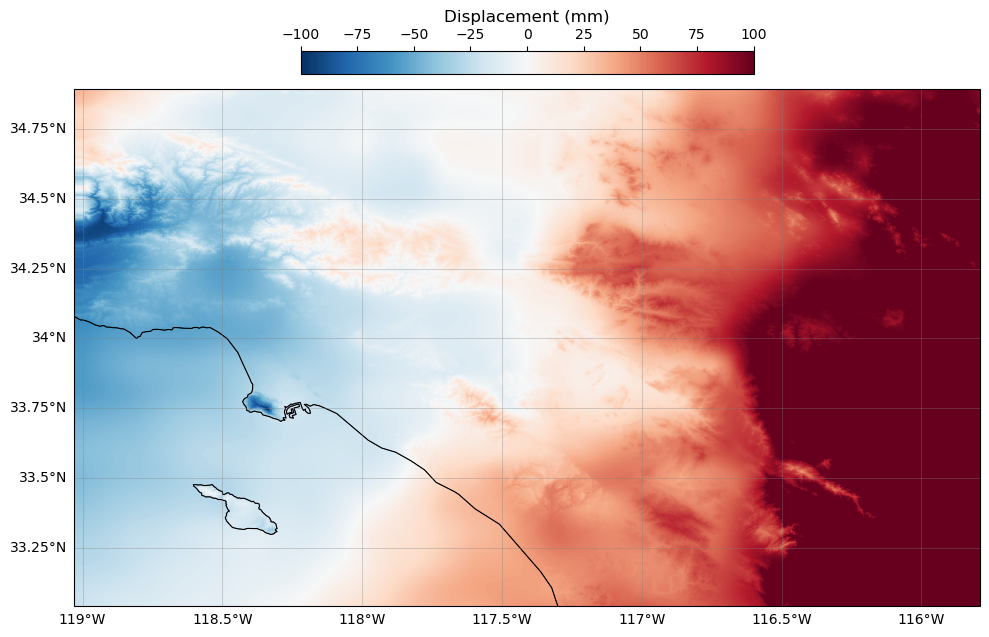

In [20]:
# Now read and plot the GACOS delays
print('Processing GACOS delays')
plot_GACOS(date1, date2, out_lats=lats, out_lons=lons, data_dir='GACOS', crange=crange)

In [22]:
print('Processing PyAPS delays')
# Download, process, and plot the PyAPS delays
# Note: sometimes the ECMWF goes down, causing a MARS error with this command. 
# If that happens, typically you can wait for a few hours and it should come back up.
plot_pyaps(date1, date2, lats=lats, lons=lons, dem_file='dem.tif', model='ERA5', crange=crange)

Processing PyAPS delays
